# ESC-50: does the CNN rely on digital silence?

20% of the ESC-50 clips are more than 10% *digital silence*: exact zeros used to pad short sounds to
5 s. The amount of padding depends on the class (glass breaking, sneezing and coughing are the most
padded), so it is a possible shortcut, and one that does not exist in the real world: a microphone
never outputs exact zeros, it always picks up some background noise.

**Experiment.** Take the trained models (one per fold, trained in Colab) and classify the
test clips again after adding pink noise, as a real microphone would, at 60, 40 and 20 dB SNR
(measured on the non-silent part). No retraining. **Control group**: clips without padding get exactly
the same treatment. If padded clips lose much more accuracy than the others, the network was using
the silence.

Two models: `cnn_freq`, trained on the clean clips, and `cnn_noise`, the same network trained with
background noise (white, pink and brown, 10 to 60 dB SNR, mixed into the spectrograms by adding
powers). The test noise is always pink and added to the waveform, so it is not exactly what
`cnn_noise` saw in training.

In [1]:
%load_ext autoreload
%autoreload 2

import zlib
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from audiolab.deep import predict_with_saved_folds
from audiolab.esc50 import load_clip, load_metadata
from audiolab.features import extract_logmel
from audiolab.model import AudioCNN
from audiolab.processing import add_noise

DATA = Path("../data")
ROOT = DATA / "ESC-50"
meta = load_metadata(ROOT)
y = meta.target.to_numpy()
folds = meta.fold.to_numpy()
class_names = meta.drop_duplicates("target").set_index("target").category.sort_index()
MODELS = {"cnn_freq": "trained on clean clips", "cnn_noise": "trained with background noise"}
make_model = lambda: AudioCNN(n_classes=50, n_freq=128, keep_frequency=True)

## 1. Spectrograms with background noise

Same pipeline as in training (load at 44.1 kHz, resample to 22.05 kHz, log-mel), with the noise
added before resampling. The noise is seeded per clip, so the experiment is reproducible.

In [2]:
SNRS = [60, 40, 20]

def noisy_logmels(snr_db):
    cache = DATA / "cache" / f"esc50_logmel128_22k_pink{snr_db}.npy"
    if cache.exists():
        return np.load(cache)
    S = []
    for fn in meta.filename:
        x, fs = load_clip(ROOT, fn)                                   # original 44.1 kHz
        x = add_noise(x, snr_db, rng=zlib.crc32(f"{fn}{snr_db}".encode()))
        S.append(extract_logmel(librosa.resample(x, orig_sr=fs, target_sr=22050), 22050))
    S = np.array(S)
    np.save(cache, S)
    return S

zero_frac = np.array([np.mean(load_clip(ROOT, fn)[0] == 0) for fn in meta.filename])
padded = zero_frac > 0.1
print(f"Padded clips (>10% digital silence): {padded.sum()} | not padded: {(~padded).sum()}")

spectrograms = {"clean": np.load(DATA / "cache" / "esc50_logmel128_22k.npy")}
for snr in SNRS:
    spectrograms[f"{snr} dB"] = noisy_logmels(snr)

Padded clips (>10% digital silence): 404 | not padded: 1596


## 2. Accuracy with and without padding

In [3]:
preds = {(model, cond): predict_with_saved_folds(DATA / "models" / model, make_model, S, folds)
         for model in MODELS for cond, S in spectrograms.items()}

gpu = np.load(DATA / "results" / "cnn_freq_gpu.npz")["pred"]
assert np.array_equal(preds["cnn_freq", "clean"], gpu), "the saved models must reproduce the training predictions"

rows = []
for (model, cond), p in preds.items():
    ok = p == y
    rows.append({"model": model, "condition": cond, "all clips": ok.mean(),
                 "padded clips": ok[padded].mean(), "not padded (control)": ok[~padded].mean()})
table = pd.DataFrame(rows).set_index(["model", "condition"])
table.style.format("{:.1%}")

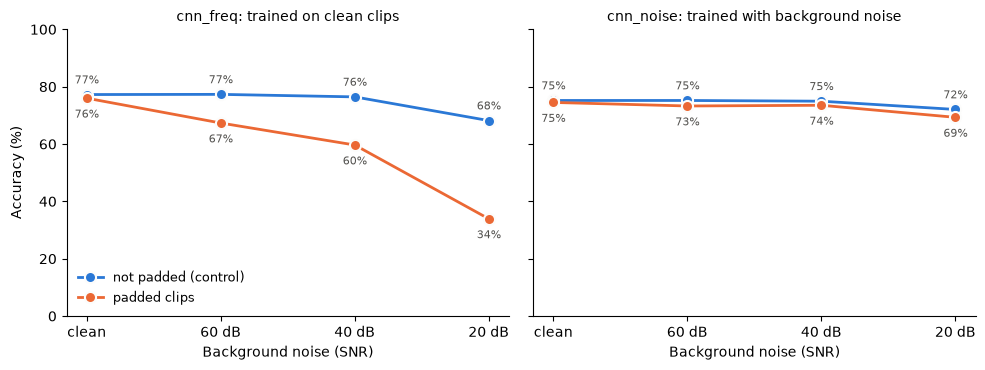

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
x = np.arange(len(spectrograms))
for ax, (model, title) in zip(axes, MODELS.items()):
    t = table.loc[model]
    for col, color in [("not padded (control)", "#2a78d6"), ("padded clips", "#eb6834")]:
        ax.plot(x, t[col] * 100, color=color, linewidth=2, marker="o", markersize=8,
                markeredgecolor="#fcfcfb", markeredgewidth=1.5, label=col)
        for i, v in enumerate(t[col]):
            above = col.startswith("not")
            ax.annotate(f"{v:.0%}", (i, v * 100), xytext=(0, 8 if above else -14), textcoords="offset points",
                        ha="center", fontsize=8, color="#52514e")
    ax.set_xticks(x, ["clean", "60 dB", "40 dB", "20 dB"])
    ax.set_xlabel("Background noise (SNR)")
    ax.set_title(f"{model}: {title}", fontsize=10)
    ax.set_ylim(0, 100)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(loc="lower left", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 3. Which classes suffer, and does the noise training fix them?

In [5]:
acc_class = lambda p: pd.Series(p == y).groupby(y).mean().to_numpy()
per_class = pd.DataFrame({
    "padding": pd.Series(zero_frac).groupby(y).mean().to_numpy(),
    "cnn_freq clean": acc_class(preds["cnn_freq", "clean"]),
    "cnn_freq 40 dB": acc_class(preds["cnn_freq", "40 dB"]),
    "cnn_noise clean": acc_class(preds["cnn_noise", "clean"]),
    "cnn_noise 40 dB": acc_class(preds["cnn_noise", "40 dB"]),
}, index=class_names)
per_class["drop cnn_freq"] = per_class["cnn_freq clean"] - per_class["cnn_freq 40 dB"]
per_class["drop cnn_noise"] = per_class["cnn_noise clean"] - per_class["cnn_noise 40 dB"]
per_class.sort_values("drop cnn_freq", ascending=False).head(10).style.format("{:.0%}")

,padding,cnn_freq clean,cnn_freq 40 dB,cnn_noise clean,cnn_noise 40 dB,drop cnn_freq,drop cnn_noise
category,,,,,,,
glass_breaking,55%,90%,38%,95%,95%,52%,0%
rooster,38%,88%,57%,88%,85%,30%,3%
coughing,40%,72%,45%,62%,62%,27%,0%
car_horn,24%,85%,70%,85%,82%,15%,3%
breathing,18%,88%,75%,85%,75%,12%,10%
door_wood_knock,40%,92%,80%,98%,100%,12%,-3%
fireworks,1%,78%,65%,65%,65%,12%,0%
dog,17%,85%,72%,75%,75%,12%,0%
helicopter,3%,30%,20%,18%,15%,10%,2%


In [6]:
for model in MODELS:
    r = np.corrcoef(per_class["padding"], per_class[f"drop {model}"])[0, 1]
    print(f"{model:9s}: correlation between padding and drop at 40 dB, r = {r:+.2f}")

cnn_freq : correlation between padding and drop at 40 dB, r = +0.67
cnn_noise: correlation between padding and drop at 40 dB, r = -0.06


## Conclusions

- **The clean-trained CNN uses digital silence as a shortcut.** Noise 60 dB below the sound, barely
  audible, leaves the clips without padding untouched (77.3% → 77.3%) but costs the padded ones 9
  points (76.0% → 67.3%), and 42 points at 20 dB. Across classes, padding and accuracy drop correlate
  with r = 0.67: glass breaking falls from 90% to 38% at 40 dB.
- **Training with background noise removes it.** `cnn_noise` keeps padded and unpadded clips together
  at every noise level (73.5% vs 74.9% at 40 dB, 69.3% vs 72.1% at 20 dB), and the correlation between
  padding and drop vanishes (r = -0.06). Glass breaking stays at 95% with noise.
- **The price is 2 points on the clean benchmark** (75.0% vs 77.0%, within run-to-run noise plus the
  shortcut it can no longer use), **the gain is 10 points at 20 dB** (71.5% vs 61.3%) and 35 points on
  padded clips. For a device that listens through a real microphone, `cnn_noise` is the model to use.
- Caveat: training (white/pink/brown, added to the spectrogram) and test noise (pink, added to the
  waveform) are both synthetic. The real test is the live microphone demo.